# 1. Import Libraries & Datasets

In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [354]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [355]:
# Define the base path for your data once
data_base_path = '/content/drive/MyDrive/Personal Work/March Madness/Data'

# Tourney
df1_t_results = pd.read_csv(f'{data_base_path}/MNCAATourneyDetailedResults.csv')
df_seed = pd.read_csv(f'{data_base_path}/MNCAATourneySeeds.csv')
df_conferences = pd.read_csv(f'{data_base_path}/MTeamConferences.csv')
df_teams = pd.read_csv(f'{data_base_path}/MTeams.csv')
df_tourney_results = pd.read_csv(f"{data_base_path}/MNCAATourneyCompactResults.csv")
coaches = pd.read_csv(f"{data_base_path}/MTeamCoaches.csv")

# Regular Season
df_regular_season = pd.read_csv(f'{data_base_path}/MRegularSeasonDetailedResults.csv')

In [356]:
df1_t_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19


In [357]:
pd.set_option('display.max_rows', None) # Display all rows
pd.set_option('display.max_columns', None) # Display all columns
pd.set_option('display.width', None) # Auto-detect display width
pd.set_option('display.max_colwidth', None) # Display full column content

print("Pandas display options have been set to show full DataFrames. Please re-run the `display(scout_one_liner(1395))` cell.")

Pandas display options have been set to show full DataFrames. Please re-run the `display(scout_one_liner(1395))` cell.


# 2. Make Predictions


Intuition would make you think keeping season aggregates would make the most sense, however, season aggregates can skew data if not given context. A team that averages 70 pts a game in 2005 was considered elite, today that is average, but the model would be left to believe today's team is better. SO by using differential offensive, defensive perfromances, we can normalize scoring biases + difference in time period.

# Testing

### Create Lookup Table for easy interpretation: I want to start with retrieving the 64 teams and their names, to easily understand results in the tournement. We will use "df_teams, df_seed" to match the names and create a dataframe as a look up table.

In [358]:
df_teams

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026
5,1106,Alabama St,1985,2026
6,1107,SUNY Albany,2000,2026
7,1108,Alcorn St,1985,2026
8,1109,Alliant Intl,1985,1991
9,1110,American Univ,1985,2026


In [359]:
df_seeds_2026 = df_seed[df_seed['Season'] == 2026]

df_seeds_2026

,Season,Seed,TeamID
2626,2026,W01,1181
2627,2026,W02,1163
2628,2026,W03,1277
2629,2026,W04,1242
2630,2026,W05,1385
2631,2026,W06,1257
2632,2026,W07,1417
2633,2026,W08,1326
2634,2026,W09,1395
2635,2026,W10,1416


In [360]:
df_seeds_2026 = df_seed[df_seed['Season'] == 2026]
# Set 'TeamID' as the index for both DataFrames before joining
df_team_names_26 = pd.merge(df_teams, df_seeds_2026, on='TeamID', how='inner')
df_team_names_26['seed_number'] = df_team_names_26['Seed'].str.extract(r'(\d+)').astype(int)

In [361]:
df_team_names_26[df_team_names_26['seed_number'] == 11]

,TeamID,TeamName,FirstD1Season,LastD1Season,Season,Seed,seed_number
29,1275,Miami OH,1985,2026,2026,Y11a,11
34,1301,NC State,1985,2026,2026,Z11a,11
44,1374,SMU,1985,2026,2026,Y11b,11
45,1378,South Florida,1985,2026,2026,W11,11
52,1400,Texas,1985,2026,2026,Z11b,11
60,1433,VCU,1985,2026,2026,X11,11


In [362]:
#Drop 4 16 seeds
drop_team_ids = [1250, 1420, 1374, 1301]
df_team_names_26 = df_team_names_26[~df_team_names_26['TeamID'].isin(drop_team_ids)]

In [363]:
df_team_names_26.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 0 to 67
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TeamID         64 non-null     int64 
 1   TeamName       64 non-null     object
 2   FirstD1Season  64 non-null     int64 
 3   LastD1Season   64 non-null     int64 
 4   Season         64 non-null     int64 
 5   Seed           64 non-null     object
 6   seed_number    64 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 4.0+ KB


In [364]:
df_team_name_lookup_2026 = df_team_names_26[['TeamID', 'TeamName', 'Seed', 'seed_number']]

In [365]:
df_team_name_lookup_2026.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 0 to 67
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   TeamID       64 non-null     int64 
 1   TeamName     64 non-null     object
 2   Seed         64 non-null     object
 3   seed_number  64 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 2.5+ KB


In [366]:
df_seeds_2025 = df_seed[(df_seed['Season'] > 2010) & (df_seed['Season'] != 2021) & (df_seed['Season'] != 2026)]
# Set 'TeamID' as the index for both DataFrames before joining
df_team_names_25 = pd.merge(df_teams, df_seeds_2025, on='TeamID', how='inner')
df_team_names_25['seed_number'] = df_team_names_25['Seed'].str.extract(r'(\d+)').astype(int)

In [367]:
df_seeds_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 884 entries, 1674 to 2625
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Season  884 non-null    int64 
 1   Seed    884 non-null    object
 2   TeamID  884 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 27.6+ KB


In [368]:
df_team_names_lookup_2025 = df_team_names_25[['TeamID', 'TeamName', 'Seed', 'seed_number']]

In [369]:
df_team_names_lookup_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   TeamID       884 non-null    int64 
 1   TeamName     884 non-null    object
 2   Seed         884 non-null    object
 3   seed_number  884 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 27.8+ KB


### Data Preprocessing: Normalize, and set up training data with "df_regular_season, df1_t_results"

In [370]:
#Load Tourney Results up to 2025
df1_t_results_07 = df1_t_results[(df1_t_results['Season'] != 2021) & (df1_t_results['Season'] > 2007)]

In [371]:
#Load regular Season Data up to 2025

df_regular_season_up_to_2025 = df_regular_season[(df_regular_season['Season'] != 2021) & (df_regular_season['Season'] > 2010)]

I want to build profiles for teams based off the regular season to use as a look up features for the tournement. I will start with Avg Points for, Points Allowed, Field Goal Percentage, 3 pt field goal percentage, Assists, Turnovers, steals, blocks. I will then join these profiles to each tourney game to help the model understand the relationships. then finally I will test it on the 2026 bracket.

In [372]:
# Here we need to adjust for home court advantage as the tournement is hosted on nuetral courts

def apply_hca_normalization(df):
    hca_val = 3.5

    # Create copies so we don't overwrite raw data immediately
    df['Points_Neutral'] = df['Score'].astype(float)
    df['OppPoints_Neutral'] = df['OppScore'].astype(float)

    # 1. Adjust the Score (The 'Subject' Team)
    # If they were Home (H), they had an advantage, so we subtract 3.5
    # If they were Away (A), they had a disadvantage, so we add 3.5
    df.loc[df['WLoc'] == 'H', 'Points_Neutral'] -= hca_val
    df.loc[df['WLoc'] == 'A', 'Points_Neutral'] += hca_val

    # 2. Adjust the Opponent Score (To keep the margin accurate)
    # If Team was Home, Opponent was Away (Add 3.5 to Opponent)
    df.loc[df['WLoc'] == 'H', 'OppPoints_Neutral'] += hca_val
    df.loc[df['WLoc'] == 'A', 'OppPoints_Neutral'] -= hca_val

    # 3. Adjust the "Counting Stats" (Assists, Steals, Blocks)
    # We use a 5% 'Venue Tax' to normalize these
    stats_to_fix = ['Ast', 'Stl', 'Blk'] # Removed duplicates

    for stat in stats_to_fix:
        # Ensure the column is float before multiplication to avoid FutureWarning
        df[stat] = df[stat].astype(float)
        # If Home, multiply by 0.95 (reduce). If Away, multiply by 1.05 (boost).
        df.loc[df['WLoc'] == 'H', stat] *= 0.95
        df.loc[df['WLoc'] == 'A', stat] *= 1.05

    return df

In [373]:
# Build out a conference stregnth function

def build_conf_pedigree_lookup(df_tourney_results, df_teams_conf):
    # Join conferences to tourney results
    tourney = pd.merge(df_tourney_results, df_teams_conf, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID'])

    # Calculate wins per conference per season
    conf_wins = tourney.groupby(['Season', 'ConfAbbrev']).size().reset_index(name='Tourney_Wins')

    # RECURSIVE/ROLLING LOGIC:
    # For every season, calculate the average wins of that conference in the PREVIOUS 3 years
    conf_wins['Rolling_Pedigree'] = conf_wins.groupby('ConfAbbrev')['Tourney_Wins'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
    )
    return conf_wins[['Season', 'ConfAbbrev', 'Rolling_Pedigree']]

In [374]:
df = build_conf_pedigree_lookup(df1_t_results_07, df_conferences)

In [375]:
df_current_pedigree = df[df['Season'] > 2010]

In [376]:
df_current_pedigree['Rolling_Pedigree'].fillna(0)

,Rolling_Pedigree
44,2.666667
45,8.000000
46,12.000000
47,0.000000
48,7.666667
49,10.666667
50,1.000000
51,2.333333
52,1.500000
53,1.000000


In [377]:
df_current_pedigree

,Season,ConfAbbrev,Rolling_Pedigree
44,2011,a_ten,2.666667
45,2011,acc,8.000000
46,2011,big_east,12.000000
47,2011,big_south,NaN
48,2011,big_ten,7.666667
49,2011,big_twelve,10.666667
50,2011,caa,1.000000
51,2011,horizon,2.333333
52,2011,mwc,1.500000
53,2011,ovc,1.000000


In [378]:
def advanced_stats_normalization(df_long_normalized):
    # 1. Effective Field Goal Percentage (eFG%)
    # Correction: If FGA already includes FGA3, do not add FGA3 to the denominator.
    # Formula: (FGM + 0.5 * FGM3) / FGA
    df_long_normalized['eFG'] = (df_long_normalized['FGM'] + 0.5 * df_long_normalized['FGM3']) / df_long_normalized['FGA']

    # 2. Possessions (The Dean Oliver Formula)
    orp = df_long_normalized['OR'] / (df_long_normalized['OR'] + df_long_normalized['OppDR'])

    # Opponent's ability to get THEIR own misses (Needed for Defensive Possessions)
    opp_orp = df_long_normalized['OppOR'] / (df_long_normalized['OppOR'] + df_long_normalized['DR'])

    # --- 2. Offensive Possessions ---
    df_long_normalized['Possessions'] = 0.5 * (
        df_long_normalized['FGA'] +
        (0.475 * df_long_normalized['FTA']) -
        (1.07 * orp * (df_long_normalized['FGA'] - df_long_normalized['FGM'])) +
        df_long_normalized['TO']
    )

    # --- 3. Defensive Possessions (The opponent's offensive trip) ---
    df_long_normalized['Def_Possessions'] = 0.5 * (
        df_long_normalized['OppFGA'] +
        (0.475 * df_long_normalized['OppFTA']) -
        (1.07 * opp_orp * (df_long_normalized['OppFGA'] - df_long_normalized['OppFGM'])) +
        df_long_normalized['OppTO']
    )

    # --- 4. Ratios ---
    df_long_normalized['TO_Rate'] = df_long_normalized['TO'] / df_long_normalized['Possessions']

    # Net Rating: (Points Produced / Possessions) - (Points Allowed / Def_Possessions)
    # We multiply by 100 to get the standard "Points per 100 possessions"
    off_eff = (df_long_normalized['Score'] / df_long_normalized['Possessions']) * 100
    def_eff = (df_long_normalized['OppPoints_Neutral'] / df_long_normalized['Def_Possessions']) * 100

    df_long_normalized['Net_Rating'] = off_eff - def_eff

    return df_long_normalized

In [379]:
def build_season_profile(df_reg, df_conferences, df_team_names, df_pedigree_lookup):
    # --- STEP 1: Standardize Win/Loss Data (Same as your previous logic) ---
    df_w = df_reg.copy()
    win_rename = {
        'WTeamID': 'TeamID', 'WScore': 'Score', 'WLoc': 'WLoc', 'LTeamID': 'OppTeamID', 'LScore': 'OppScore',
        'WFGM': 'FGM', 'WFGA': 'FGA', 'WFGM3': 'FGM3', 'WFGA3': 'FGA3',
        'WFTM': 'FTM', 'WFTA': 'FTA', 'WOR': 'OR', 'WDR': 'DR',
        'WAst': 'Ast', 'WTO': 'TO', 'WStl': 'Stl', 'WBlk': 'Blk', 'WPF': 'PF',
        'LFGM': 'OppFGM', 'LFGA': 'OppFGA', 'LFGM3': 'OppFGM3', 'LFGA3': 'OppFGA3',
        'LFTM': 'OppFTM', 'LFTA': 'OppFTA', 'LOR': 'OppOR', 'LDR': 'OppDR',
        'LAst': 'OppAst', 'LTO': 'OppTO', 'LStl': 'OppStl', 'LBlk': 'OppBlk', 'LPF': 'OppPF'
    }

    df_l = df_reg.copy()
    lose_rename = {
        'LTeamID': 'TeamID', 'LScore': 'Score','WLoc': 'WLoc', 'WTeamID': 'OppTeamID', 'WScore': 'OppScore',
        'LFGM': 'FGM', 'LFGA': 'FGA', 'LFGM3': 'FGM3', 'LFGA3': 'FGA3',
        'LFTM': 'FTM', 'LFTA': 'FTA', 'LOR': 'OR', 'LDR': 'DR',
        'LAst': 'Ast', 'LTO': 'TO', 'LStl': 'Stl', 'LBlk': 'Blk', 'LPF': 'PF',
        'WFGM': 'OppFGM', 'WFGA': 'OppFGA', 'WFGM3': 'OppFGM3', 'WFGA3': 'OppFGA3',
        'WFTM': 'OppFTM', 'WFTA': 'OppFTA', 'WOR': 'OppOR', 'WDR': 'OppDR',
        'WAst': 'OppAst', 'WTO': 'OppTO', 'WStl': 'OppStl', 'WBlk': 'OppBlk', 'LPF': 'OppPF'
    }

    df_win = df_w.rename(columns=win_rename)
    df_lose = df_l.rename(columns=lose_rename)

    loc_map = {'H': 'A', 'A': 'H', 'N': 'N'}
    df_lose['WLoc'] = df_lose['WLoc'].map(loc_map)
    df_long_ini = pd.concat([df_win, df_lose], axis=0).reset_index(drop=True)

    # --- STEP 2: Join Conferences & Pedigree ---
    df_long = pd.merge(df_long_ini, df_conferences[['Season', 'TeamID', 'ConfAbbrev']], on=['Season', 'TeamID'], how='left')
    df_long = pd.merge(df_long, df_pedigree_lookup, on=['Season', 'ConfAbbrev'], how='left')

    # Neutralize Location Effects (HCA Adjustment)
    df_normalized = apply_hca_normalization(df_long)

    raw_def_profile = df_normalized.groupby(['Season', 'TeamID'])['OppPoints_Neutral'].mean().reset_index()
    raw_def_profile.columns = ['Season', 'OppTeamID', 'Opp_Avg_Points_Allowed']

    # --- STEP 3: Pass 2 - The "Fair Adjustment" ---
    df_adjusted = pd.merge(df_normalized, raw_def_profile, on=['Season', 'OppTeamID'], how='left')
    # Score_POE: How many points you scored vs what the opponent typically allows
    df_adjusted['Score_POE'] = df_adjusted['OppPoints_Neutral'] - df_adjusted['Opp_Avg_Points_Allowed']

    # --- STEP 4: Aggregate Games into Season Profiles (Unique Team per Season) ---
    # We exclude Pedigree here to prevent row multiplication
    season_profiles = df_adjusted.groupby(['Season', 'TeamID']).agg({
        'OppPoints_Neutral': 'mean',
        'Score': 'mean',
        'Score_POE': 'mean',
        'FGM': 'mean',
        'FGA': 'mean',
        'FGM3': 'mean',
        'FGA3': 'mean',
        'Ast': 'mean',
        'TO': 'mean',
        'Stl': 'mean',
        'Blk': 'mean',
        'FTA': 'mean',
        'OR': 'mean',
        'DR': 'mean',
        'OppDR': 'mean',
        'OppFGA': 'mean',
        'OppFGM': 'mean',
        'OppFTA': 'mean',
        'OppTO': 'mean',
        'OppOR': 'mean',
        'OppStl': 'mean',
        'OppBlk': 'mean'
    }).reset_index()

    # --- STEP 5: Apply Recursive Pedigree (Season - 1) ---
    # 1. Get the current conference for the team
    season_profiles = pd.merge(season_profiles,
                               df_conferences[['Season', 'TeamID', 'ConfAbbrev']].drop_duplicates(),
                               on=['Season', 'TeamID'], how='left')

    # 2. Prepare the Pedigree Lookup with a Season Shift
    # We want 2024 teams to see the 2023 (and prior) pedigree
    pedigree_shift = df_pedigree_lookup.copy()
    # We don't change the 'Season' column in the lookup;
    # instead, we join it to the profile's (Season) using (Lookup Season + 1)

    # Alternatively, the most robust way:
    season_profiles = pd.merge(season_profiles,
                               df_pedigree_lookup[['Season', 'ConfAbbrev', 'Rolling_Pedigree']],
                               on=['Season', 'ConfAbbrev'], how='left')

    # --- STEP 6: Final Cleanup ---
    season_profiles = pd.merge(season_profiles, df_team_names[['TeamID', 'TeamName']].drop_duplicates(),
                               on='TeamID', how='left')

    season_profiles = advanced_stats_normalization(season_profiles)
    season_profiles['Rolling_Pedigree'] = season_profiles['Rolling_Pedigree'].fillna(0)

    return season_profiles

In [380]:
df_regular_season_up_to_2025.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
39337,2011,7,1228,79,1414,65,H,0,29,58,8,24,13,23,9,30,17,14,9,8,22,22,63,7,20,14,22,11,26,12,14,7,1,21
39338,2011,7,1268,105,1370,76,H,0,35,62,2,8,33,41,17,33,23,29,9,9,20,28,77,3,16,17,22,18,16,11,27,18,1,31
39339,2011,7,1338,83,1348,75,H,0,29,64,3,15,22,30,18,28,19,14,8,6,18,24,60,14,32,13,16,10,21,16,17,7,6,25
39340,2011,7,1400,83,1298,52,H,0,30,59,4,17,19,34,11,39,16,15,5,5,17,19,63,4,23,10,18,8,22,8,16,5,5,24
39341,2011,9,1228,84,1405,45,H,0,37,64,5,18,5,6,10,28,21,14,10,7,18,16,45,3,12,10,19,6,17,9,23,6,0,14


In [381]:
df_long_normalized = build_season_profile(df_regular_season_up_to_2025, df_conferences, df_team_names_lookup_2025, df_current_pedigree)

In [382]:
df_long_normalized.head()

,Season,TeamID,OppPoints_Neutral,Score,Score_POE,FGM,FGA,FGM3,FGA3,Ast,TO,Stl,Blk,FTA,OR,DR,OppDR,OppFGA,OppFGM,OppFTA,OppTO,OppOR,OppStl,OppBlk,ConfAbbrev,Rolling_Pedigree,TeamName,eFG,Possessions,Def_Possessions,TO_Rate,Net_Rating
0,2011,1102,64.910714,64.250000,-2.449805,22.428571,47.857143,6.678571,17.750000,15.308929,11.928571,6.176786,2.480357,18.142857,5.857143,22.428571,22.857143,53.857143,22.142857,17.142857,12.964286,11.714286,5.571429,3.250000,mwc,1.500000,NaN,0.538433,31.426782,31.660780,0.379567,-0.575857
1,2011,1103,66.529412,69.970588,-1.847308,24.588235,57.205882,7.882353,21.882353,14.279412,12.029412,6.416176,3.388235,18.235294,10.058824,24.205882,25.294118,56.000000,23.352941,21.411765,13.941176,11.970588,5.970588,2.323529,mac,0.000000,Akron,0.498715,33.983429,34.276424,0.353979,11.799487
2,2011,1104,59.906250,66.656250,-8.468148,24.875000,55.906250,4.093750,13.718750,12.214063,14.187500,9.146875,5.115625,17.718750,12.593750,24.062500,21.218750,53.312500,20.437500,19.656250,15.500000,12.218750,6.093750,3.968750,sec,3.666667,Alabama,0.481554,33.071628,33.151305,0.428993,20.845600
3,2011,1105,65.680000,62.800000,-2.593346,22.160000,55.800000,4.280000,15.000000,11.608000,15.880000,8.618000,5.290000,22.760000,11.880000,24.680000,26.640000,55.760000,23.360000,23.400000,16.840000,12.720000,8.080000,4.240000,swac,0.000000,NaN,0.435484,35.694900,35.962086,0.444881,-6.701293
4,2011,1106,63.781250,61.562500,-4.459266,20.906250,52.562500,4.812500,16.468750,11.689063,15.718750,7.309375,4.587500,24.531250,13.312500,22.281250,23.500000,49.656250,20.500000,26.156250,15.593750,11.250000,7.406250,2.625000,swac,0.000000,Alabama St,0.443520,33.842199,33.603658,0.464472,-7.894028


## Set up Training Data

In [383]:
df_tourney = df_tourney_results[(df_tourney_results['Season'] != 2021) & (df_tourney_results['Season'] > 2010)]

# 1. Merge Winning Team Stats
train_df = pd.merge(df_tourney, df_long_normalized,
                    left_on=['Season', 'WTeamID'],
                    right_on=['Season', 'TeamID'],
                    how='left')

# 2. Merge Losing Team Stats
train_df = pd.merge(train_df, df_long_normalized,
                    left_on=['Season', 'LTeamID'],
                    right_on=['Season', 'TeamID'],
                    how='left', suffixes=('_W', '_L'))

daystodrop = [134, 135]
train_df = train_df[~train_df['DayNum'].isin(daystodrop)]

In [384]:
#List core Stats, use the suffixes to create a winners bracket and losers bracket, then ultiamtely join them so the model has a table with randomness forcing it to look at the stats and not just the first team.
import numpy as np
import pandas as pd

# 1. Define the stats we are comparing
base_stats = ['Score_POE', 'OppPoints_Neutral', 'Ast', 'TO', 'Stl', 'Blk', 'FTA', 'eFG', 'Possessions', 'TO_Rate', 'Net_Rating', 'Rolling_Pedigree']

# 1. Create a random "coin flip" for every game in your train_df
# 1 = Winner is Team A, 0 = Loser is Team A
np.random.seed(42) # For reproducibility
mask = np.random.randint(0, 2, size=len(train_df))

# 2. Initialize your final training list
final_rows = []

# Use enumerate to get a positional index (idx) for accessing 'mask'
for idx, (original_index, row) in enumerate(train_df.iterrows()):
    game_data = {}

    if mask[idx] == 1:
        # Case: Winner is Team A
        game_data['TeamA'] = row['TeamName_W']
        game_data['TeamB'] = row['TeamName_L']
        game_data['Result'] = 1
        for stat in base_stats:
            game_data[f'Diff_{stat}'] = row[f'{stat}_W'] - row[f'{stat}_L']
    else:
        # Case: Loser is Team A
        game_data['TeamA'] = row['TeamName_L']
        game_data['TeamB'] = row['TeamName_W']
        game_data['Result'] = 0
        for stat in base_stats:
            game_data[f'Diff_{stat}'] = row[f'{stat}_L'] - row[f'{stat}_W']

    final_rows.append(game_data)

# 3. Build the DataFrame
df_train_final = pd.DataFrame(final_rows)

# 4. Scramble (Shuffle) the entire dataset
df_train_final = df_train_final.sample(frac=1).reset_index(drop=True)

In [385]:
df_train_final.head(

)

,TeamA,TeamB,Result,Diff_Score_POE,Diff_OppPoints_Neutral,Diff_Ast,Diff_TO,Diff_Stl,Diff_Blk,Diff_FTA,Diff_eFG,Diff_Possessions,Diff_TO_Rate,Diff_Net_Rating,Diff_Rolling_Pedigree
0,Villanova,NC State,0,-6.850402,-5.190731,4.358422,0.337790,3.811943,-1.191667,2.277184,0.057458,0.110067,0.009215,35.315109,3.666667
1,Notre Dame,Northeastern,1,2.719530,1.985294,0.554412,-4.352941,1.408824,-0.302941,-0.441176,0.040298,0.405627,-0.138236,24.516398,6.000000
2,Kansas,Creighton,1,6.076175,2.504011,2.186631,-1.334225,1.025178,-0.322995,4.680927,0.031979,0.780261,-0.046646,19.972149,4.333333
3,E Kentucky,Kansas,0,-2.715319,0.830890,-0.842717,-2.407625,2.248192,-3.845259,-4.028348,0.024356,-1.287652,-0.056851,-5.235094,-6.000000
4,Villanova,Connecticut,0,2.081138,3.295956,3.062316,0.167279,-0.048529,-2.105515,4.250000,0.026064,1.575873,-0.011286,7.086712,13.333333


In [386]:
# Identify your features (Everything that starts with 'Diff_')
features = [col for col in df_train_final.columns if col.startswith('Diff_')]

# Train the model
# We ONLY give it the 'features' and the 'Result'
X = df_train_final[features]
y = df_train_final['Result']

import xgboost

model = xgboost.XGBClassifier()
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [387]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# 1. Ensure your feature list is defined in a specific order
# This order MUST match the order of your 'constraints' tuple
features = ['Diff_Score_POE','Diff_eFG', 'Diff_TO_Rate', 'Diff_OppPoints_Neutral','Diff_Net_Rating', 'Diff_FTA', 'Diff_Possessions','Diff_TO', 'Diff_Ast', 'Diff_Stl','Diff_Blk', 'Diff_Rolling_Pedigree']

# 2. Define Feature Weights based on that specific list
feature_weights_map = {
    'Diff_Score_POE': 1.3,
    'Diff_eFG': 1.3,
    'Diff_TO_Rate': 1.1,
    'Diff_OppPoints_Neutral': 1.1,
    'Diff_Net_Rating': 1,
    'Diff_FTA': 1.1,
    'Diff_Possessions': 1.1,
    'Diff_TO': 1,
    'Diff_Ast': 1,
    'Diff_Stl': 1,
    'Diff_Blk': 1,
    'Diff_Rolling_Pedigree': 1
}

# Create the weight list by iterating through the 'features' list to ensure order
weights_list = [feature_weights_map.get(f, 1.0) for f in features]


# 4. Initialize the Model
model = xgb.XGBClassifier(
    n_estimators=56,
    early_stopping_rounds=10,
    learning_rate=0.044,
    max_depth=4,
    feature_weights=weights_list,
    random_state=42,
    use_label_encoder=False,
    eval_metric=("error", 'logloss')
)



# 5. Define X and y (Ensure case consistency)
X = df_train_final[features]
y = df_train_final['Result']

# 1. Split your data (80% to train, 20% to validate)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the 'Eval Set' list
eval_set = [(X_train, y_train), (X_val, y_val)]

# 3. Fit the model with monitoring
model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=True # This prints the results to your screen live
)


print("Model Sharpened: Logic Constraints & Weights Applied correctly.")

[0]	validation_0-error:0.36031	validation_0-logloss:0.68022	validation_1-error:0.40854	validation_1-logloss:0.68511
[1]	validation_0-error:0.32366	validation_0-logloss:0.66914	validation_1-error:0.38415	validation_1-logloss:0.67731
[2]	validation_0-error:0.25649	validation_0-logloss:0.65833	validation_1-error:0.34756	validation_1-logloss:0.67136
[3]	validation_0-error:0.24885	validation_0-logloss:0.64875	validation_1-error:0.33537	validation_1-logloss:0.66393
[4]	validation_0-error:0.24885	validation_0-logloss:0.64003	validation_1-error:0.32927	validation_1-logloss:0.65750
[5]	validation_0-error:0.24885	validation_0-logloss:0.63149	validation_1-error:0.31098	validation_1-logloss:0.65346
[6]	validation_0-error:0.24580	validation_0-logloss:0.62339	validation_1-error:0.31707	validation_1-logloss:0.64798
[7]	validation_0-error:0.23511	validation_0-logloss:0.61540	validation_1-error:0.31707	validation_1-logloss:0.64472
[8]	validation_0-error:0.23664	validation_0-logloss:0.60837	validation_1

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [03:45:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[18]	validation_0-error:0.22443	validation_0-logloss:0.54975	validation_1-error:0.31707	validation_1-logloss:0.60810
[19]	validation_0-error:0.21832	validation_0-logloss:0.54463	validation_1-error:0.31098	validation_1-logloss:0.60666
[20]	validation_0-error:0.21832	validation_0-logloss:0.53997	validation_1-error:0.30488	validation_1-logloss:0.60492
[21]	validation_0-error:0.21679	validation_0-logloss:0.53562	validation_1-error:0.31098	validation_1-logloss:0.60235
[22]	validation_0-error:0.22137	validation_0-logloss:0.53138	validation_1-error:0.31098	validation_1-logloss:0.60091
[23]	validation_0-error:0.21832	validation_0-logloss:0.52750	validation_1-error:0.30488	validation_1-logloss:0.59847
[24]	validation_0-error:0.21679	validation_0-logloss:0.52363	validation_1-error:0.31707	validation_1-logloss:0.59608
[25]	validation_0-error:0.20611	validation_0-logloss:0.51966	validation_1-error:0.30488	validation_1-logloss:0.59495
[26]	validation_0-error:0.20611	validation_0-logloss:0.51600	val

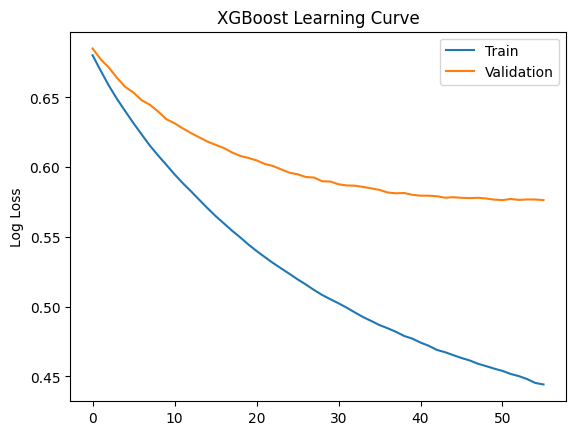

In [388]:
results = model.evals_result()
epochs = len(results['validation_0']['error'])
x_axis = range(0, epochs)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(x_axis, results['validation_0']['logloss'], label='Train')
ax.plot(x_axis, results['validation_1']['logloss'], label='Validation')
ax.legend()
plt.ylabel('Log Loss')
plt.title('XGBoost Learning Curve')
plt.show()

### Now to the fun part we can begin training data, we will join our tournement results

# Now we Test on the 2026 Tournement

In [389]:
df_regular_season_2026 = df_regular_season[df_regular_season['Season'] == 2026]

In [390]:
df_long_normalized_26 = build_season_profile(df_regular_season_2026, df_conferences, df_team_name_lookup_2026, df_current_pedigree)

In [391]:
df_long_normalized_26 = df_long_normalized_26[df_long_normalized_26['TeamName'].notna()]

In [392]:
df_current_pedigree_26 = df_current_pedigree[df_current_pedigree['Season'] == 2025]
df_current_pedigree_26

,Season,ConfAbbrev,Rolling_Pedigree
225,2025,acc,11.000000
226,2025,big_east,9.666667
227,2025,big_ten,8.333333
228,2025,big_twelve,9.666667
229,2025,maac,1.666667
230,2025,mvc,2.666667
231,2025,mwc,3.666667
232,2025,sec,7.333333
233,2025,southland,1.000000
234,2025,swac,1.000000


In [393]:
df_long_normalized_26 = pd.merge(df_long_normalized_26, df_current_pedigree_26, how='left', left_on='ConfAbbrev', right_on='ConfAbbrev', suffixes=('', '_w'))

In [394]:
df_long_normalized_26.head()

,Season,TeamID,OppPoints_Neutral,Score,Score_POE,FGM,FGA,FGM3,FGA3,Ast,TO,Stl,Blk,FTA,OR,DR,OppDR,OppFGA,OppFGM,OppFTA,OppTO,OppOR,OppStl,OppBlk,ConfAbbrev,Rolling_Pedigree,TeamName,eFG,Possessions,Def_Possessions,TO_Rate,Net_Rating,Season_w,Rolling_Pedigree_w
0,2026,1103,74.609375,86.875000,-1.808681,31.156250,62.593750,10.875000,28.250000,17.779688,10.531250,7.228125,2.867188,18.187500,9.562500,24.656250,19.718750,60.562500,26.031250,18.343750,12.375000,9.375000,6.281250,2.843750,mac,0.0,Akron,0.584623,35.389360,35.736074,0.297582,36.704511,NaN,NaN
1,2026,1104,84.015625,91.718750,8.036457,30.156250,65.875000,12.656250,35.343750,15.928125,9.437500,6.353125,5.009375,24.500000,10.187500,26.687500,24.531250,68.906250,29.843750,22.500000,9.281250,11.687500,6.406250,3.687500,sec,0.0,Alabama,0.553843,37.867703,38.072666,0.249223,21.536616,2025.0,7.333333
2,2026,1112,69.514706,86.147059,-4.999915,30.558824,60.852941,5.882353,16.323529,16.686765,10.529412,7.705882,4.186765,26.088235,11.588235,28.147059,18.852941,62.617647,24.529412,17.352941,11.823529,9.147059,6.029412,3.705882,big_twelve,0.0,Arizona,0.550507,35.717377,36.344032,0.294798,49.922334,2025.0,9.666667
3,2026,1116,80.911765,89.941176,4.609447,32.088235,64.176471,8.323529,21.411765,16.716176,8.823529,7.170588,5.055882,23.352941,9.441176,23.176471,21.852941,63.941176,28.970588,20.029412,10.852941,9.794118,5.029412,2.852941,sec,0.0,Arkansas,0.564849,36.867119,36.596341,0.239333,22.867913,2025.0,7.333333
4,2026,1140,75.941176,83.911765,2.832569,29.705882,62.264706,8.647059,24.764706,13.304412,10.529412,7.113235,4.394118,21.264706,10.500000,24.323529,21.794118,61.264706,27.117647,17.705882,11.088235,8.647059,6.294118,2.970588,big_twelve,0.0,BYU,0.546528,35.783881,35.590368,0.294250,21.120341,2025.0,9.666667


In [395]:
# This permanently replaces NaN with 0 in the column
#df_long_normalized_26['Rolling_Pedigree_w'] = df_long_normalized_26['Rolling_Pedigree_w'].fillna(0)
df_long_normalized_26['Rolling_Pedigree'] = df_long_normalized_26['Rolling_Pedigree_w']

In [396]:
base_stats = ['Score_POE','eFG', 'TO_Rate', 'OppPoints_Neutral','Net_Rating', 'FTA', 'Possessions','TO', 'Ast', 'Stl','Blk', 'Rolling_Pedigree']

def get_scouting_report(matchup_list, profiles_df, model, base_stats):
    """
    Takes a list of (ID_A, ID_B) tuples and returns a scouting report
    with win probabilities based on the provided model and profiles.
    """
    # 1. Convert tuples to a DataFrame
    df_matchups = pd.DataFrame(matchup_list, columns=['TeamA_ID', 'TeamB_ID'])

    # 2. Merge Stats for Team A
    df_predict = pd.merge(df_matchups, profiles_df,
                         left_on='TeamA_ID', right_on='TeamID', how='left')

    # 3. Merge Stats for Team B
    df_predict = pd.merge(df_predict, profiles_df,
                         left_on='TeamB_ID', right_on='TeamID',
                         how='left', suffixes=('_A', '_B'))

    # 4. Calculate the Deltas (Differences)
    features = []
    for stat in base_stats:
        diff_col = f'Diff_{stat}'
        df_predict[diff_col] = df_predict[f'{stat}_A'] - df_predict[f'{stat}_B']
        features.append(diff_col)

    # 5. Predict Win Probabilities
    # [:, 1] gets the probability of Team A winning
    df_predict['Win_Prob_A'] = model.predict_proba(df_predict[features])[:, 1]

    # 6. Return a clean, sorted Scouting Report
    scouting_report = df_predict[['TeamName_A', 'TeamName_B', 'Win_Prob_A'] + features]

    return scouting_report.sort_values(by='Win_Prob_A', ascending=False)

In [397]:
# (TeamA_ID, TeamB_ID) pairs for all 32 Round of 64 games
# Team A is the winner in each pair based on the results provided
matchups_round_1 = [
    (1395, 1326), (1304, 1407), (1257, 1378), (1219, 1458),
    (1181, 1373), (1435, 1270), (1277, 1295), (1116, 1218),
    (1433, 1314), (1276, 1224), (1400, 1140), (1401, 1388),
    (1228, 1335), (1387, 1208), (1211, 1244), (1222, 1225),
    (1246, 1365), (1403, 1103), (1112, 1254), (1438, 1460),
    (1235, 1398), (1104, 1220), (1429, 1437), (1397, 1275),
    (1234, 1155), (1385, 1320), (1345, 1474), (1417, 1416),
    (1196, 1341), (1242, 1465), (1274, 1281), (1163, 1202)
]

round_of_64 = get_scouting_report(matchups_round_1, df_long_normalized_26, model, base_stats)
print(round_of_64[['TeamName_A', 'TeamName_B', 'Win_Prob_A']])

     TeamName_A      TeamName_B  Win_Prob_A
31  Connecticut          Furman    0.877892
19     Virginia       Wright St    0.864477
15      Houston           Idaho    0.855932
1      Nebraska            Troy    0.854619
26       Purdue       Queens NC    0.837605
20      Iowa St    Tennessee St    0.837245
28      Florida    Prairie View    0.810291
30     Miami FL        Missouri    0.801663
3    High Point       Wisconsin    0.786399
9      Michigan          Howard    0.781622
18      Arizona    LIU Brooklyn    0.778092
23    Tennessee        Miami OH    0.774304
8           VCU  North Carolina    0.772658
4          Duke           Siena    0.765876
2    Louisville   South Florida    0.765537
17   Texas Tech           Akron    0.757305
7      Arkansas          Hawaii    0.755669
12     Illinois            Penn    0.746557
21      Alabama         Hofstra    0.730982
27         UCLA             UCF    0.717155
29       Kansas     Cal Baptist    0.714942
25    St John's   Northern Iowa 

In [398]:
# 1. Define the Round 2 Pairs (Winners are Team A)
r2_pairs = [
    (1276, 1387), (1277, 1257), (1181, 1395), (1222, 1401),
    (1400, 1211), (1228, 1433), (1304, 1435), (1116, 1219),
    (1345, 1274), (1235, 1246), (1385, 1242), (1397, 1438),
    (1234, 1196), (1112, 1429), (1163, 1417), (1104, 1403)
]

round_of_32 = get_scouting_report(r2_pairs, df_long_normalized_26, model, base_stats)

print(round_of_32[['TeamName_A', 'TeamName_B', 'Win_Prob_A']])

     TeamName_A  TeamName_B  Win_Prob_A
13      Arizona     Utah St    0.821978
5      Illinois         VCU    0.787664
0      Michigan    St Louis    0.784355
14  Connecticut        UCLA    0.758008
10    St John's      Kansas    0.751191
3       Houston   Texas A&M    0.741916
7      Arkansas  High Point    0.652858
15      Alabama  Texas Tech    0.622404
8        Purdue    Miami FL    0.621403
9       Iowa St    Kentucky    0.610377
2          Duke         TCU    0.593967
6      Nebraska  Vanderbilt    0.443982
1   Michigan St  Louisville    0.436491
12         Iowa     Florida    0.412010
11    Tennessee    Virginia    0.372088
4         Texas     Gonzaga    0.214072


In [399]:
# (TeamA_ID, TeamB_ID) pairs for the 8 Sweet 16 games
# Team A is the winner in each pair based on the results provided
matchups_round_3 = [
    (1345, 1400), # Purdue vs Texas
    (1234, 1304), # Iowa vs Nebraska
    (1112, 1116), # Arizona vs Arkansas
    (1228, 1222), # Illinois vs Houston
    (1181, 1385), # Duke vs St John's
    (1276, 1104), # Michigan vs Alabama
    (1163, 1277), # Connecticut vs Michigan St
(1397, 1235)  # Tennessee vs Iowa St
]

sweet_16 = get_scouting_report(matchups_round_3, df_long_normalized_26, model, base_stats)

print(sweet_16[['TeamName_A', 'TeamName_B', 'Win_Prob_A']])

    TeamName_A   TeamName_B  Win_Prob_A
5     Michigan      Alabama    0.795765
6  Connecticut  Michigan St    0.773702
0       Purdue        Texas    0.746442
2      Arizona     Arkansas    0.679321
4         Duke    St John's    0.595128
7    Tennessee      Iowa St    0.528990
3     Illinois      Houston    0.476894
1         Iowa     Nebraska    0.456898


In [400]:
sweet_16

,TeamName_A,TeamName_B,Win_Prob_A,Diff_Score_POE,Diff_eFG,Diff_TO_Rate,Diff_OppPoints_Neutral,Diff_Net_Rating,Diff_FTA,Diff_Possessions,Diff_TO,Diff_Ast,Diff_Stl,Diff_Blk,Diff_Rolling_Pedigree
5,Michigan,Alabama,0.795765,-11.563291,0.026803,0.076664,-14.397978,25.962467,-1.823529,-2.037920,2.238971,2.413051,-0.706066,0.855331,1.000000
6,Connecticut,Michigan St,0.773702,-3.288350,0.017391,-0.011043,-3.436581,7.836116,-3.599265,-0.380268,-0.488971,-0.014430,1.754688,1.177574,1.333333
0,Purdue,Texas,0.746442,-4.223859,0.033968,-0.032995,-6.821659,18.725949,-9.530876,-2.160247,-1.711521,7.954332,-0.024654,-0.144332,1.000000
2,Arizona,Arkansas,0.679321,-9.609362,-0.014341,0.055465,-11.397059,27.054421,2.735294,-1.149743,1.705882,-0.029412,0.535294,-0.869118,2.333333
4,Duke,St John's,0.595128,-6.639453,0.057691,0.021774,-7.132353,26.470397,-3.735294,-2.199357,0.117647,0.780882,-0.080882,-1.567647,1.333333
7,Tennessee,Iowa St,0.528990,1.281370,-0.049080,0.040150,4.238414,-11.092661,3.196078,-0.629440,1.179144,-0.368182,-1.409492,0.873574,-2.333333
3,Illinois,Houston,0.476894,8.424090,0.029693,0.015569,7.004596,-2.843673,3.788603,0.791579,0.709559,0.053401,-3.885937,0.764430,-1.333333
1,Iowa,Nebraska,0.456898,-0.200798,0.011154,0.005435,-0.487689,-4.032751,2.575758,-1.963094,-0.375947,-2.556345,-0.144413,-0.542803,0.000000


In [401]:
# Run the Elite 8 (Round 4)
r4_matchups = [(1228, 1234), (1112, 1345), (1276, 1397), (1163, 1181)]
elite_8_report = get_scouting_report(r4_matchups, df_long_normalized_26, model, base_stats)

print(elite_8_report[['TeamName_A', 'TeamName_B', 'Win_Prob_A']])

    TeamName_A TeamName_B  Win_Prob_A
2     Michigan  Tennessee    0.765583
0     Illinois       Iowa    0.701145
1      Arizona     Purdue    0.669144
3  Connecticut       Duke    0.328235


In [402]:
elite_8_report

,TeamName_A,TeamName_B,Win_Prob_A,Diff_Score_POE,Diff_eFG,Diff_TO_Rate,Diff_OppPoints_Neutral,Diff_Net_Rating,Diff_FTA,Diff_Possessions,Diff_TO,Diff_Ast,Diff_Stl,Diff_Blk,Diff_Rolling_Pedigree
2,Michigan,Tennessee,0.765583,3.729915,0.065028,-0.001546,-0.488414,16.310286,-0.990196,1.957532,0.585561,1.709358,-1.780214,2.313191,1.000000
0,Illinois,Iowa,0.701145,3.987604,-0.014905,-0.027525,3.972064,12.934251,1.830492,1.574923,-0.467803,-0.645218,-3.307150,2.600616,0.000000
1,Arizona,Purdue,0.669144,-1.992214,-0.025663,0.033823,-1.228151,15.589902,8.973950,3.092411,2.015126,-3.004664,2.227311,1.468193,1.333333
3,Connecticut,Duke,0.328235,1.874937,-0.014314,0.009145,2.176471,-18.530299,-4.470588,-0.518043,0.147059,1.347059,-0.914706,1.976471,-1.333333


In [403]:
# Run the Final Four (Round 5)
r5_matchups = [(1163, 1228), (1276, 1112)]
final_four_report = get_scouting_report(r5_matchups, df_long_normalized_26, model, base_stats)

print(final_four_report[['TeamName_A', 'TeamName_B', 'Win_Prob_A']])

    TeamName_A TeamName_B  Win_Prob_A
1     Michigan    Arizona    0.506956
0  Connecticut   Illinois    0.361092


In [404]:
final_four_report

,TeamName_A,TeamName_B,Win_Prob_A,Diff_Score_POE,Diff_eFG,Diff_TO_Rate,Diff_OppPoints_Neutral,Diff_Net_Rating,Diff_FTA,Diff_Possessions,Diff_TO,Diff_Ast,Diff_Stl,Diff_Blk,Diff_Rolling_Pedigree
1,Michigan,Arizona,0.506956,1.473081,0.030138,0.031089,0.102941,-2.423251,-3.411765,0.112406,1.147059,1.654412,-2.058824,1.677941,-1.333333
0,Connecticut,Illinois,0.361092,-5.282850,0.002755,0.053871,-4.842831,-3.666954,-2.818015,-0.103619,1.761029,3.673070,3.085938,0.638511,1.333333


In [405]:
# National Championship: Michigan vs. Connecticut
championship_matchup = [(1276, 1163)]

# Run your new function
final_report = get_scouting_report(championship_matchup, df_long_normalized_26, model, base_stats)

print("--- 2026 NATIONAL CHAMPIONSHIP PREDICTION ---")
print(final_report[['TeamName_A', 'TeamName_B', 'Win_Prob_A']])

--- 2026 NATIONAL CHAMPIONSHIP PREDICTION ---
  TeamName_A   TeamName_B  Win_Prob_A
0   Michigan  Connecticut     0.68275


In [406]:
#Results

"""Model Correctly Predicted
  Round 1:27/32
  Round 2: 11/16
  Round 3: 6/8
  Round 4: 3/4
  Round 5: 2/2
  Round 6:

  Results: 50/62 = 81%

  """

'Model Correctly Predicted\n  Round 1:27/32\n  Round 2: 11/16\n  Round 3: 6/8\n  Round 4: 3/4\n  Round 5: 2/2\n  Round 6:\n\n  Results: 50/62 = 81%\n\n  '

# Refinement

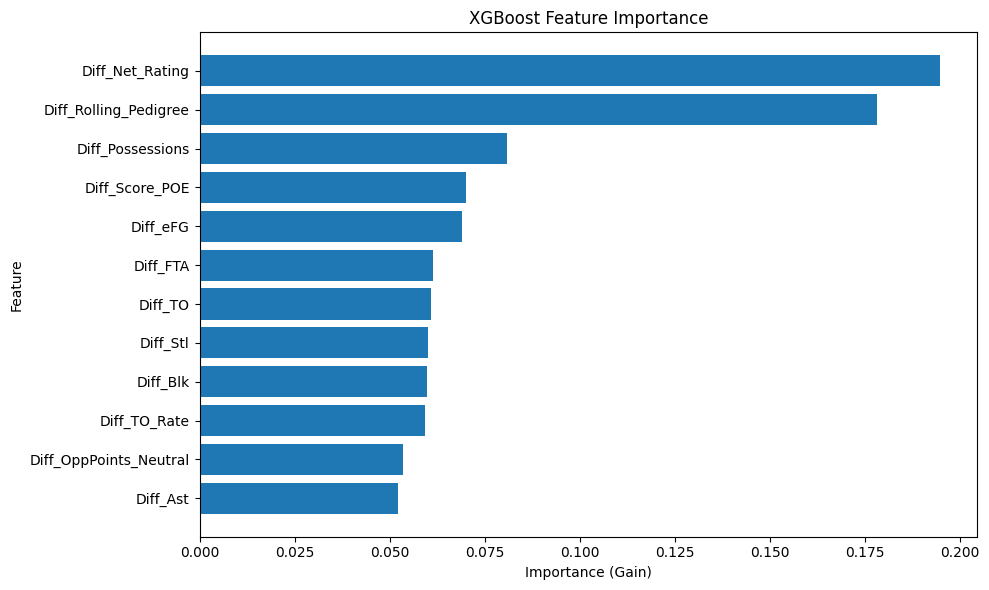

In [407]:
# 1. Get the importance dictionary from the model
# 'gain' is usually the most accurate measure for "Importance"
importance = model.get_booster().get_score(importance_type='gain')

# 2. Map the technical names (f0, f1) back to your actual feature names
# Assuming 'features' is your list: ['Diff_Power_Score', 'Diff_eFG', etc.]
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

# Sort for better visualization
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6)) # Optional: set figure size
plt.barh(feature_importance['Feature'], feature_importance['Importance']) # Use barh for horizontal bars
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Model Results

In [408]:
Final_results = pd.concat([round_of_64, round_of_32, sweet_16, elite_8_report, final_four_report, final_report])

In [409]:
print(np.sum(Final_results['Win_Prob_A'] > 0.50) / len(Final_results))

0.7936507936507936


In [410]:
def calc_round_perf(df1, df2, df3, df4, df5, df6):
    score1 = np.sum(df1['Win_Prob_A'] > 0.50) / len(df1) * 100
    score2 = np.sum(df2['Win_Prob_A'] > 0.50) / len(df2) * 100
    score3 = np.sum(df3['Win_Prob_A'] > 0.50) / len(df3) * 100
    score4 = np.sum(df4['Win_Prob_A'] > 0.50) / len(df4) * 100
    score5 = np.sum(df5['Win_Prob_A'] > 0.50) / len(df5) * 100
    score6 = np.sum(df6['Win_Prob_A'] > 0.50) / len(df6) * 100

    score_list = list([score1, score2, score3, score4, score5, score6])

    return score_list

In [411]:
results = calc_round_perf(round_of_64, round_of_32, sweet_16, elite_8_report, final_four_report, final_report)

In [412]:
list(results)

[np.float64(87.5),
 np.float64(68.75),
 np.float64(75.0),
 np.float64(75.0),
 np.float64(50.0),
 np.float64(100.0)]

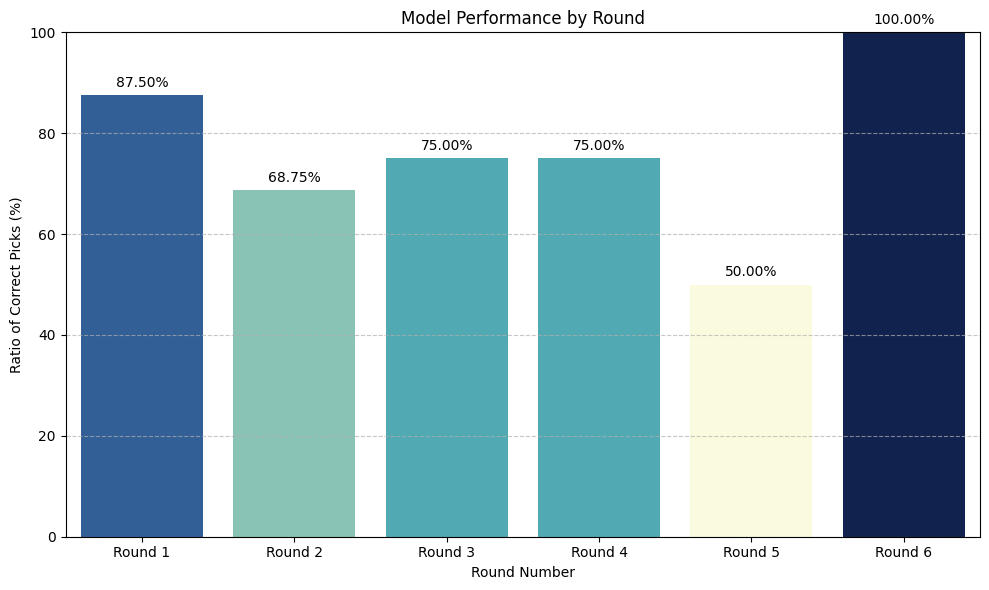

In [415]:
import seaborn as sns
import pandas as pd

rounds_labels = [f'Round {i}' for i in range(1, 7)] # Create labels for each round

# Create a DataFrame for plotting to easily use 'hue' for color gradient
plot_df = pd.DataFrame({
    'Round': rounds_labels,
    'Performance': results
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Round', y='Performance', hue='Performance', data=plot_df, palette='YlGnBu', legend=False) # Use 'Performance' for hue and a sequential palette

plt.title('Model Performance by Round')
plt.xlabel('Round Number')
plt.ylabel('Ratio of Correct Picks (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid only on y-axis for cleaner look

# Add percentage values on top of each bar
for index, value in enumerate(plot_df['Performance']):
    plt.text(index, value + 1, f'{value:.2f}%', color='black', ha="center", va='bottom') # Adjust va for placement

plt.ylim(0, 100) # Set y-axis limit to 0-100 for percentages
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()